# The Frugal Parameterization for Bayesian Causal Inference in PyMC

**References:**
- Evans, R.J. & Didelez, V. (2024). *Parameterizing and simulating from causal models.* Journal of the Royal Statistical Society Series B, 86(3), 535–568. [DOI](https://doi.org/10.1093/jrsssb/qkad058)
- Steiner, G. & Steel, M.F.J. (2024). Discussion contribution to Evans & Didelez. JRSS-B, 86(3), 580–582.
- Evans, R.J. (2023). `causl`: R package for specifying, simulating from and fitting causal models. [GitHub](https://github.com/rje42/causl)  


## Motivation: Why Do We Need a New Parameterization?

### The standard approach and its limitations

Bayesian causal inference typically proceeds as follows:

1. **Specify a full generative model** for the joint distribution of treatment, outcome, and confounders using conditional distributions.
2. **Fit the model** using MCMC or variational inference.
3. **Derive the causal estimand** (e.g., the Average Treatment Effect) as a function of the posterior over model parameters.

For example, consider a simple setting with a confounder $Z$, a binary treatment $X$, and a continuous outcome $Y$. The causal graph is:



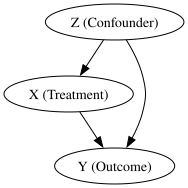

In [1]:
import graphviz as gr

g = gr.Digraph(comment="Causal Graph")

g.node("Z", "Z (Confounder)")
g.node("X", "X (Treatment)")
g.node("Y", "Y (Outcome)")

g.edge("Z", "X")
g.edge("Z", "Y")
g.edge("X", "Y")

g

The standard Bayesian model would be:

$$
Z \sim \text{Normal}(0, 1)
$$
$$
X \mid Z \sim \text{Bernoulli}\!\left(\text{logit}^{-1}(\alpha_0 + \alpha_1 Z)\right)
$$
$$
Y \mid X, Z \sim \text{Normal}(\beta_0 + \beta_1 X + \beta_2 Z, \, \sigma^2)
$$

The **Average Treatment Effect** (ATE) is:

$$
\text{ATE} = \mathbb{E}[Y \mid \text{do}(X=1)] - \mathbb{E}[Y \mid \text{do}(X=0)]
$$

In this linear model, the ATE happens to equal $\beta_1$. But this is a **coincidence of the linear specification**. In general, with non-linear models, interactions, or non-Gaussian outcomes, the ATE is a complex function of all model parameters.

This creates three practical problems:

**Problem 1: You can't put a prior directly on the causal effect.** Your priors go on regression coefficients ($\beta_0, \beta_1, \beta_2$), not on the quantity you actually care about. If a domain expert says *"we believe this treatment reduces the outcome by 10–20%"*, translating that into priors on regression coefficients is awkward and indirect, especially in non-linear models.

**Problem 2: Simulation with known causal effects is difficult.** If you want to generate synthetic data where the *true* ATE has a specific value (for benchmarking, power analysis, or sensitivity analysis), you can't just set it. You have to reverse-engineer which conditional parameters would produce the desired marginal causal effect. As Havercroft & Didelez (2012) showed, this is surprisingly hard even in seemingly simple longitudinal settings.

**Problem 3: Likelihood-based inference on marginal causal quantities is indirect.** The causal estimand is a marginal quantity of the *interventional* distribution, but the data comes from the *observational* distribution. You fit the full conditional model and then post-process the posterior. This is inefficient and can be numerically unstable.   


## The Frugal Parameterization

### Core idea

Evans & Didelez (2024) propose to **flip the parameterization**: instead of starting with conditional distributions and deriving the causal effect, start with the causal effect and build the rest of the joint distribution around it.

The joint observational distribution $P(Z, X, Y)$ is decomposed into three **variation-independent** components:

| Component | What it represents | What you specify |
|---|---|---|
| **(a) "The past"** | $P(Z, X)$ | Confounder distribution + propensity score |
| **(b) Causal margin** | $P^*(Y \mid \text{do}(X))$ | Interventional outcome distribution |
| **(c) Dependence** | Association between $Y$ and $Z$ beyond $X$ | Copula or odds ratio |

The term **"frugal"** refers to the fact that this parameterization uses exactly the parameters needed — no more, no less — with the causal quantity of interest at the center.

### Why "variation independent"?

The three components can be changed independently of each other. This is crucial for Bayesian inference because, as Steiner & Steel (2024) noted in their discussion of the paper, variation independence naturally maps to **prior independence** in a Bayesian context. You can put a prior on the causal effect without that prior implicitly constraining the propensity model or the dependence structure.

### The Gaussian copula case

For continuous outcomes with Gaussian margins, the dependence component (c) can be parameterized using a **Gaussian copula** with correlation parameter $\rho$.

Concretely, let:
- $\mu(x) = \mu_0 + \delta \cdot x$ be the mean of $Y$ under intervention $\text{do}(X=x)$
- $\sigma_c$ be the standard deviation of $Y$ under intervention
- $\rho$ be the Gaussian copula correlation between $Y$ and $Z$ given $X$

Then the **observational** conditional distribution $Y \mid X, Z$ has a closed-form expression:

$$
Y \mid X=x, Z=z \;\sim\; \text{Normal}\!\left(
  \underbrace{(\mu_0 + \delta \cdot x)}_{\text{causal margin mean}}
  + \underbrace{\rho \cdot \sigma_c \cdot z}_{\text{copula adjustment}},
  \;\; \sigma_c^2 (1 - \rho^2)
\right)
$$

where we have assumed $Z$ is standardized ($\mu_Z = 0, \sigma_Z = 1$).

**Key observation:** The parameter $\delta$ is the ATE. It is now a *direct* model parameter, not a derived quantity. We can put a prior on it: $\delta \sim \mathcal{N}(0, 2)$ (vague) or $\delta \sim \mathcal{N}(0.5, 0.1)$ (informative, from a pilot experiment).

The copula correlation $\rho$ absorbs the confounding association between $Z$ and $Y$ that is *not* mediated by the treatment $X$. It plays the role that $\beta_2$ plays
in the standard regression, but it is parameterized in terms of the copula rather than a regression coefficient.

### Deriving the observational likelihood (optional details)

For readers who want to understand *why* the conditional distribution has the form above, here is a brief derivation.

Under a Gaussian copula, the joint distribution of $(Y^*, Z)$ in the interventional world (where $X$ is set by intervention) is:

$$
\begin{pmatrix} Y^* \\ Z \end{pmatrix} \sim
\text{MultivariateNormal}\!\left(
  \begin{pmatrix} \mu(x) \\ 0 \end{pmatrix},
  \begin{pmatrix} \sigma_c^2 & \rho \sigma_c \\ \rho \sigma_c & 1 \end{pmatrix}
\right)
$$

The conditional $Y^* \mid Z = z$ under intervention is:

$$
Y^* \mid Z=z \;\sim\; \mathcal{N}\!\left(
  \mu(x) + \rho \sigma_c \cdot z, \;\; \sigma_c^2(1 - \rho^2)
\right)
$$

Now, the key assumption (from the causal model) is that in the *observational* distribution, the conditional $Y \mid X, Z$ equals the conditional $Y^* \mid Z$ under intervention $\text{do}(X=x)$, given the standard identifiability assumptions (no unmeasured confounding conditional on $Z$). This gives us the likelihood we use for inference.

**Connection to the standard parameterization:** If we set $\beta_0 = \mu_0$, $\beta_1 = \delta$, $\beta_2 = \rho \sigma_c$, and $\sigma = \sigma_c \sqrt{1 - \rho^2}$, we recover the standard regression. The difference is that the frugal version parameterizes $\delta$ directly rather than embedding it in the regression structure.


We now implement both parameterizations side by side in PyMC and compare them on synthetic data.

## Prepare Notebook

In [2]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor.tensor as pt
from pymc import do

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [3]:
seed: int = 41
rng: np.random.Generator = np.random.default_rng(seed=seed)

We generate data from a simple causal model:

- A confounder $Z \sim \text{Normal}(0, 1)$
- A treatment $X \mid Z \sim \text{Bernoulli}(\text{logit}^{-1}(-0.5 + 0.8 Z))$
- An outcome $Y \mid X, Z \sim \text{Normal}(1.0 + 0.5 X + 0.7 Z, \, 1.0)$

The **true ATE** is $\delta = 0.5$.

In [ ]:
N = 500
alpha_0, alpha_1 = -0.5, 0.8
beta_0, beta_1, beta_2 = 1.0, 0.5, 0.7
sigma_y = 1

TRUE_ATE = beta_1

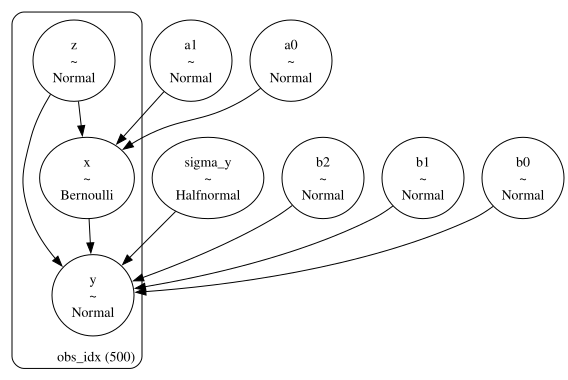

In [5]:
coords = {"obs_idx": np.arange(N)}

with pm.Model(coords=coords) as generative_model:
    _z = pm.Normal("z", 0, 1, dims="obs_idx")

    _a0 = pm.Normal("a0", 0, 2)
    _a1 = pm.Normal("a1", 0, 2)
    _b0 = pm.Normal("b0", 0, 2)
    _b1 = pm.Normal("b1", 0, 2)
    _b2 = pm.Normal("b2", 0, 2)
    _sigma_y = pm.HalfNormal("sigma_y", 1)

    _x = pm.Bernoulli("x", p=pm.math.invlogit(_a0 + _a1 * _z), dims="obs_idx")

    _mu_y = _b0 + _b1 * _x + _b2 * _z
    pm.Normal("y", mu=_mu_y, sigma=_sigma_y, dims="obs_idx")

pm.model_to_graphviz(generative_model)

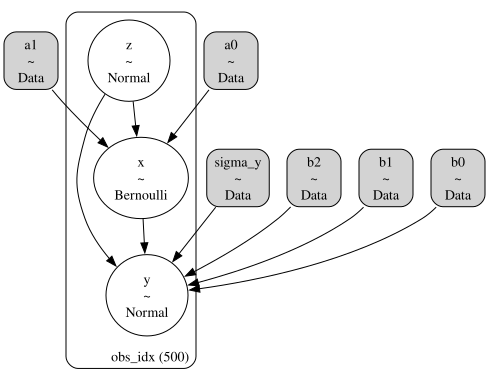

In [6]:
conditioned_generative_model = do(
    generative_model,
    {
        "a0": alpha_0,
        "a1": alpha_1,
        "b0": beta_0,
        "b1": beta_1,
        "b2": beta_2,
        "sigma_y": sigma_y,
    },
)

pm.model_to_graphviz(conditioned_generative_model)

In [7]:
with conditioned_generative_model:
    prior_samples = pm.sample_prior_predictive(draws=1, random_seed=rng)

Sampling: [x, y, z]


In [8]:
z_obs = prior_samples["prior"]["z"].sel(chain=0, draw=0).to_numpy()
x_obs = prior_samples["prior"]["x"].sel(chain=0, draw=0).to_numpy()
y_obs = prior_samples["prior"]["y"].sel(chain=0, draw=0).to_numpy()

## Standard parameterization

This is the conventional Bayesian regression approach. We specify the full conditional model and put priors on the regression coefficients.

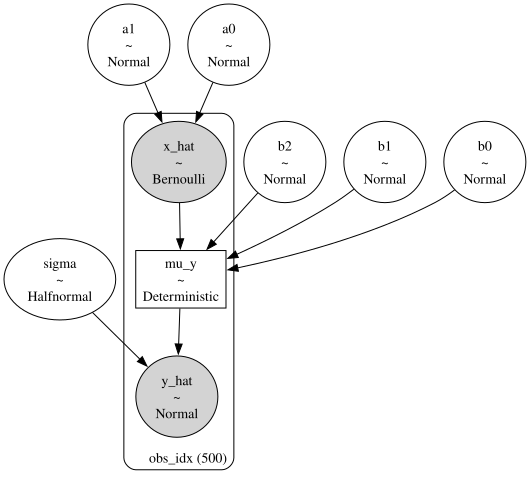

In [9]:
coords = {"obs_idx": np.arange(N)}

with pm.Model(coords=coords) as standard_model:
    a0 = pm.Normal("a0", 0, 2)
    a1 = pm.Normal("a1", 0, 2)
    b0 = pm.Normal("b0", 0, 2)
    b1 = pm.Normal("b1", 0, 2)  # ATE = b1 (only in the linear case!)
    b2 = pm.Normal("b2", 0, 2)
    sigma = pm.HalfNormal("sigma", 2)

    x_hat = pm.Bernoulli(
        "x_hat", p=pm.math.invlogit(a0 + a1 * z_obs), observed=x_obs, dims="obs_idx"
    )

    mu_y = pm.Deterministic("mu_y", b0 + b1 * x_hat + b2 * z_obs, dims="obs_idx")
    pm.Normal("y_hat", mu=mu_y, sigma=sigma, observed=y_obs, dims="obs_idx")


pm.model_to_graphviz(standard_model)

In [10]:
with standard_model:
    idata_standard = pm.sample(
        draws=2_000,
        tune=1_000,
        chains=4,
        random_seed=seed,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a0, a1, b0, b1, b2, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


In [11]:
az.summary(idata_standard, var_names=["b0", "b1", "b2", "sigma"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b0,1.040,0.057,0.932,1.148,0.001,0.001,6256.0,5385.0,1.0
b1,0.498,0.095,0.313,0.671,0.001,0.001,5761.0,4987.0,1.0
b2,0.657,0.045,0.574,0.745,0.001,0.000,7497.0,6094.0,1.0
sigma,0.970,0.031,0.913,1.027,0.000,0.000,8808.0,6535.0,1.0


In the standard model, the ATE posterior is simply the posterior of `b1`. Note that this only works because the model is linear — in a non-linear model, we would need to compute $\text{ATE} = \mathbb{E}_Z[g(1, Z) - g(0, Z)]$ over posterior samples of $g$, which is more involved.

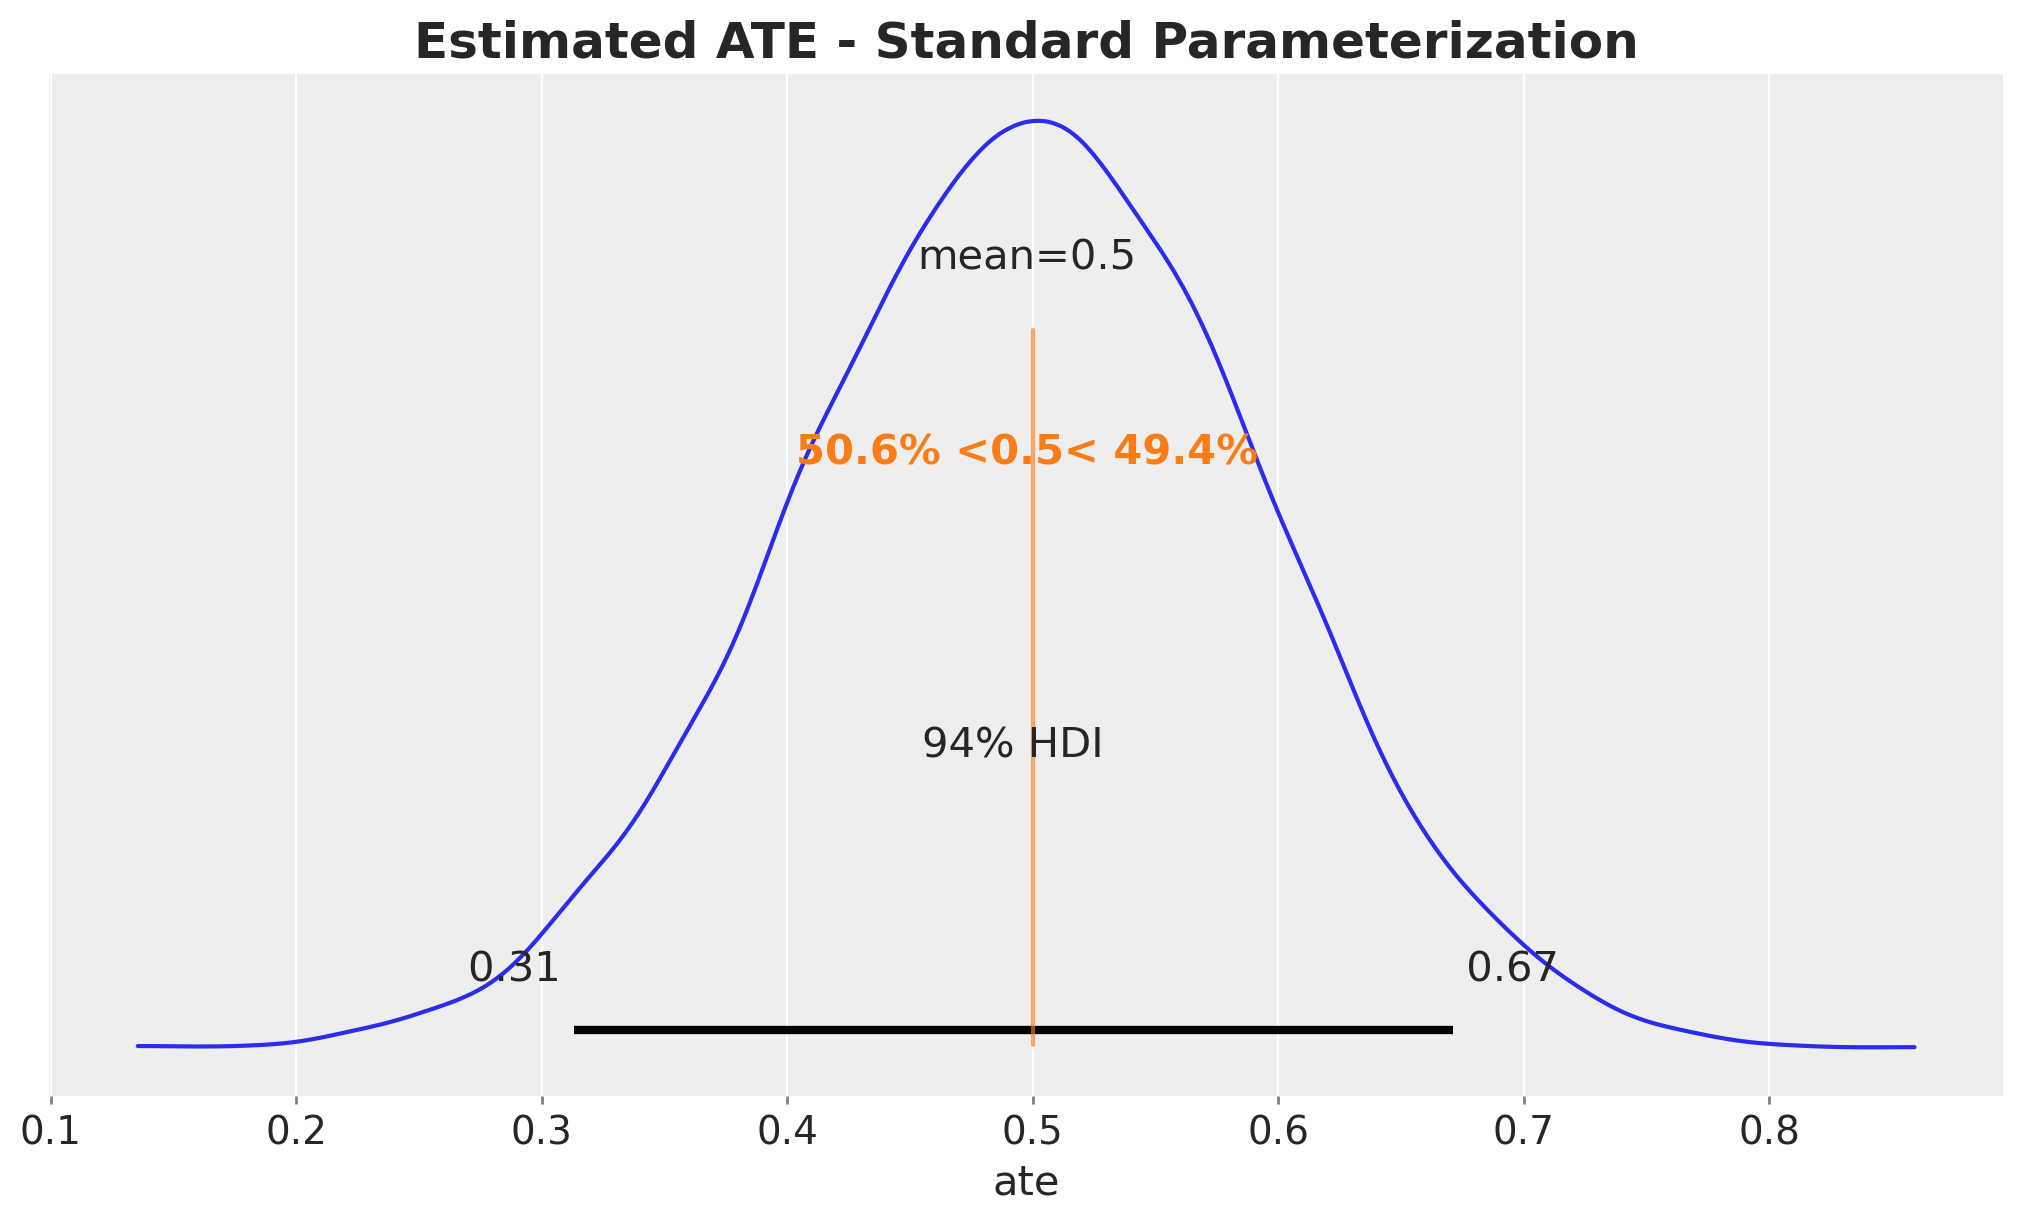

In [12]:
fig, ax = plt.subplots()
az.plot_posterior(idata_standard, var_names=["b1"], ref_val=TRUE_ATE, ax=ax)
ax.set(xlabel="ate")
ax.set_title(
    "Estimated ATE - Standard Parameterization", fontsize=18, fontweight="bold"
);

## Frugal parameterization

Now we implement the frugal parameterization. The model has three blocks:

1. **The past** $P(Z, X)$: same propensity model as before.
2. **Causal margin** $P^*(Y \mid \text{do}(X))$: parameterized by $\mu_0$
   (baseline outcome), $\delta$ (ATE), and $\sigma_c$ (causal SD).
3. **Dependence**: Gaussian copula correlation $\rho$ between $Y$ and $Z$.

The observational likelihood is:

$$
Y \mid X=x, Z=z \sim \text{Normal}\!\left(
  (\mu_0 + \delta x) + \rho \sigma_c z, \;\;
  \sigma_c^2 (1 - \rho^2)
\right)
$$

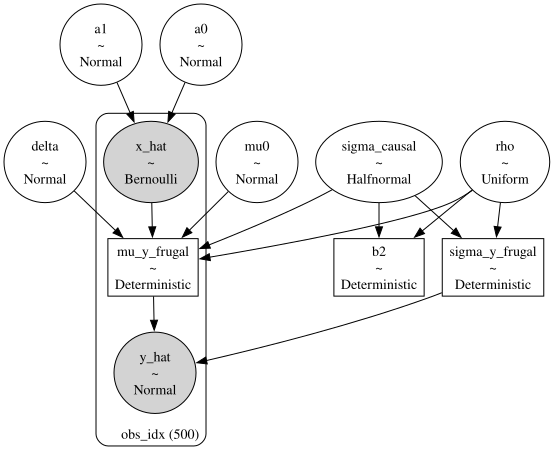

In [13]:
with pm.Model(coords=coords) as frugal_model:
    # --- (a) The past: propensity model P(X|Z) ---
    a0 = pm.Normal("a0", 0, 2)
    a1 = pm.Normal("a1", 0, 2)
    x_hat = pm.Bernoulli(
        "x_hat", p=pm.math.invlogit(a0 + a1 * z_obs), observed=x_obs, dims="obs_idx"
    )

    # --- (b) Causal margin: P*(Y | do(X)) ---
    mu0 = pm.Normal("mu0", 0, 2)  # E[Y | do(X=0)]
    delta = pm.Normal("delta", 0, 2)  # ATE (direct parameter!)
    sigma_causal = pm.HalfNormal("sigma_causal", 1)

    # --- (c) Dependence: Gaussian copula ---
    rho = pm.Uniform("rho", -0.95, 0.95)

    b2 = pm.Deterministic("b2", rho * sigma_causal)

    # --- Observational likelihood ---
    mu_y_frugal = pm.Deterministic(
        "mu_y_frugal", mu0 + delta * x_hat + rho * sigma_causal * z_obs, dims="obs_idx"
    )
    sigma_y_frugal = pm.Deterministic(
        "sigma_y_frugal",
        sigma_causal * pt.sqrt(1 - rho**2),
    )

    pm.Normal(
        "y_hat", mu=mu_y_frugal, sigma=sigma_y_frugal, observed=y_obs, dims="obs_idx"
    )

pm.model_to_graphviz(frugal_model)

In [14]:
with frugal_model:
    idata_frugal = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        random_seed=seed,
        progressbar=True,
        return_inferencedata=True,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a0, a1, mu0, delta, sigma_causal, rho]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


In [15]:
az.summary(idata_frugal, var_names=["mu0", "delta", "sigma_causal", "rho"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu0,1.040,0.057,0.938,1.152,0.001,0.001,6969.0,6496.0,1.0
delta,0.500,0.092,0.322,0.672,0.001,0.001,6420.0,5828.0,1.0
sigma_causal,1.170,0.036,1.103,1.237,0.000,0.000,7806.0,6491.0,1.0
rho,0.558,0.030,0.501,0.611,0.000,0.000,7323.0,6751.0,1.0


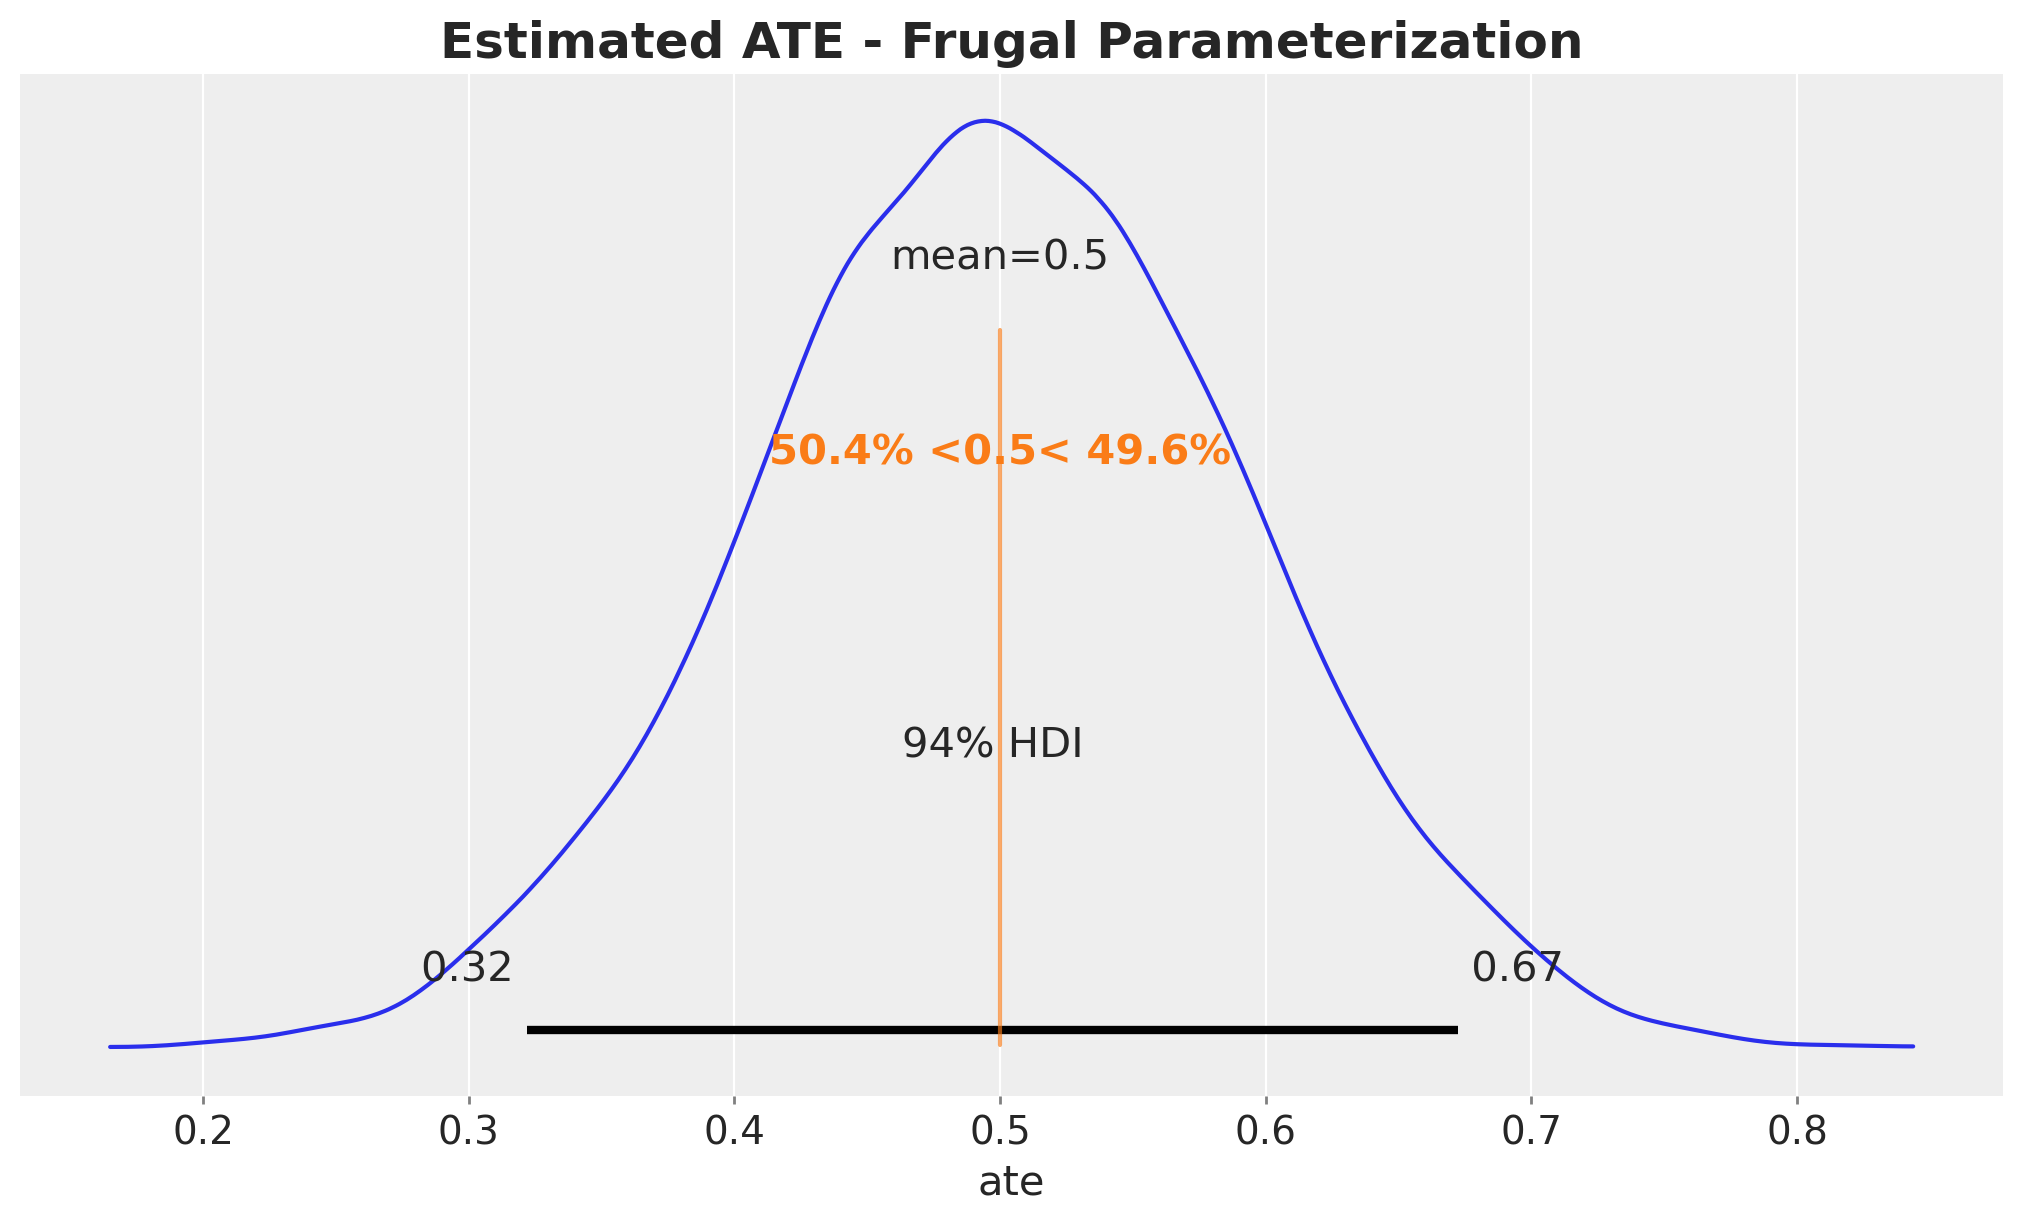

In [16]:
fig, ax = plt.subplots()
az.plot_posterior(idata_frugal, var_names=["delta"], ref_val=TRUE_ATE, ax=ax)
ax.set(xlabel="ate")
ax.set_title("Estimated ATE - Frugal Parameterization", fontsize=18, fontweight="bold");

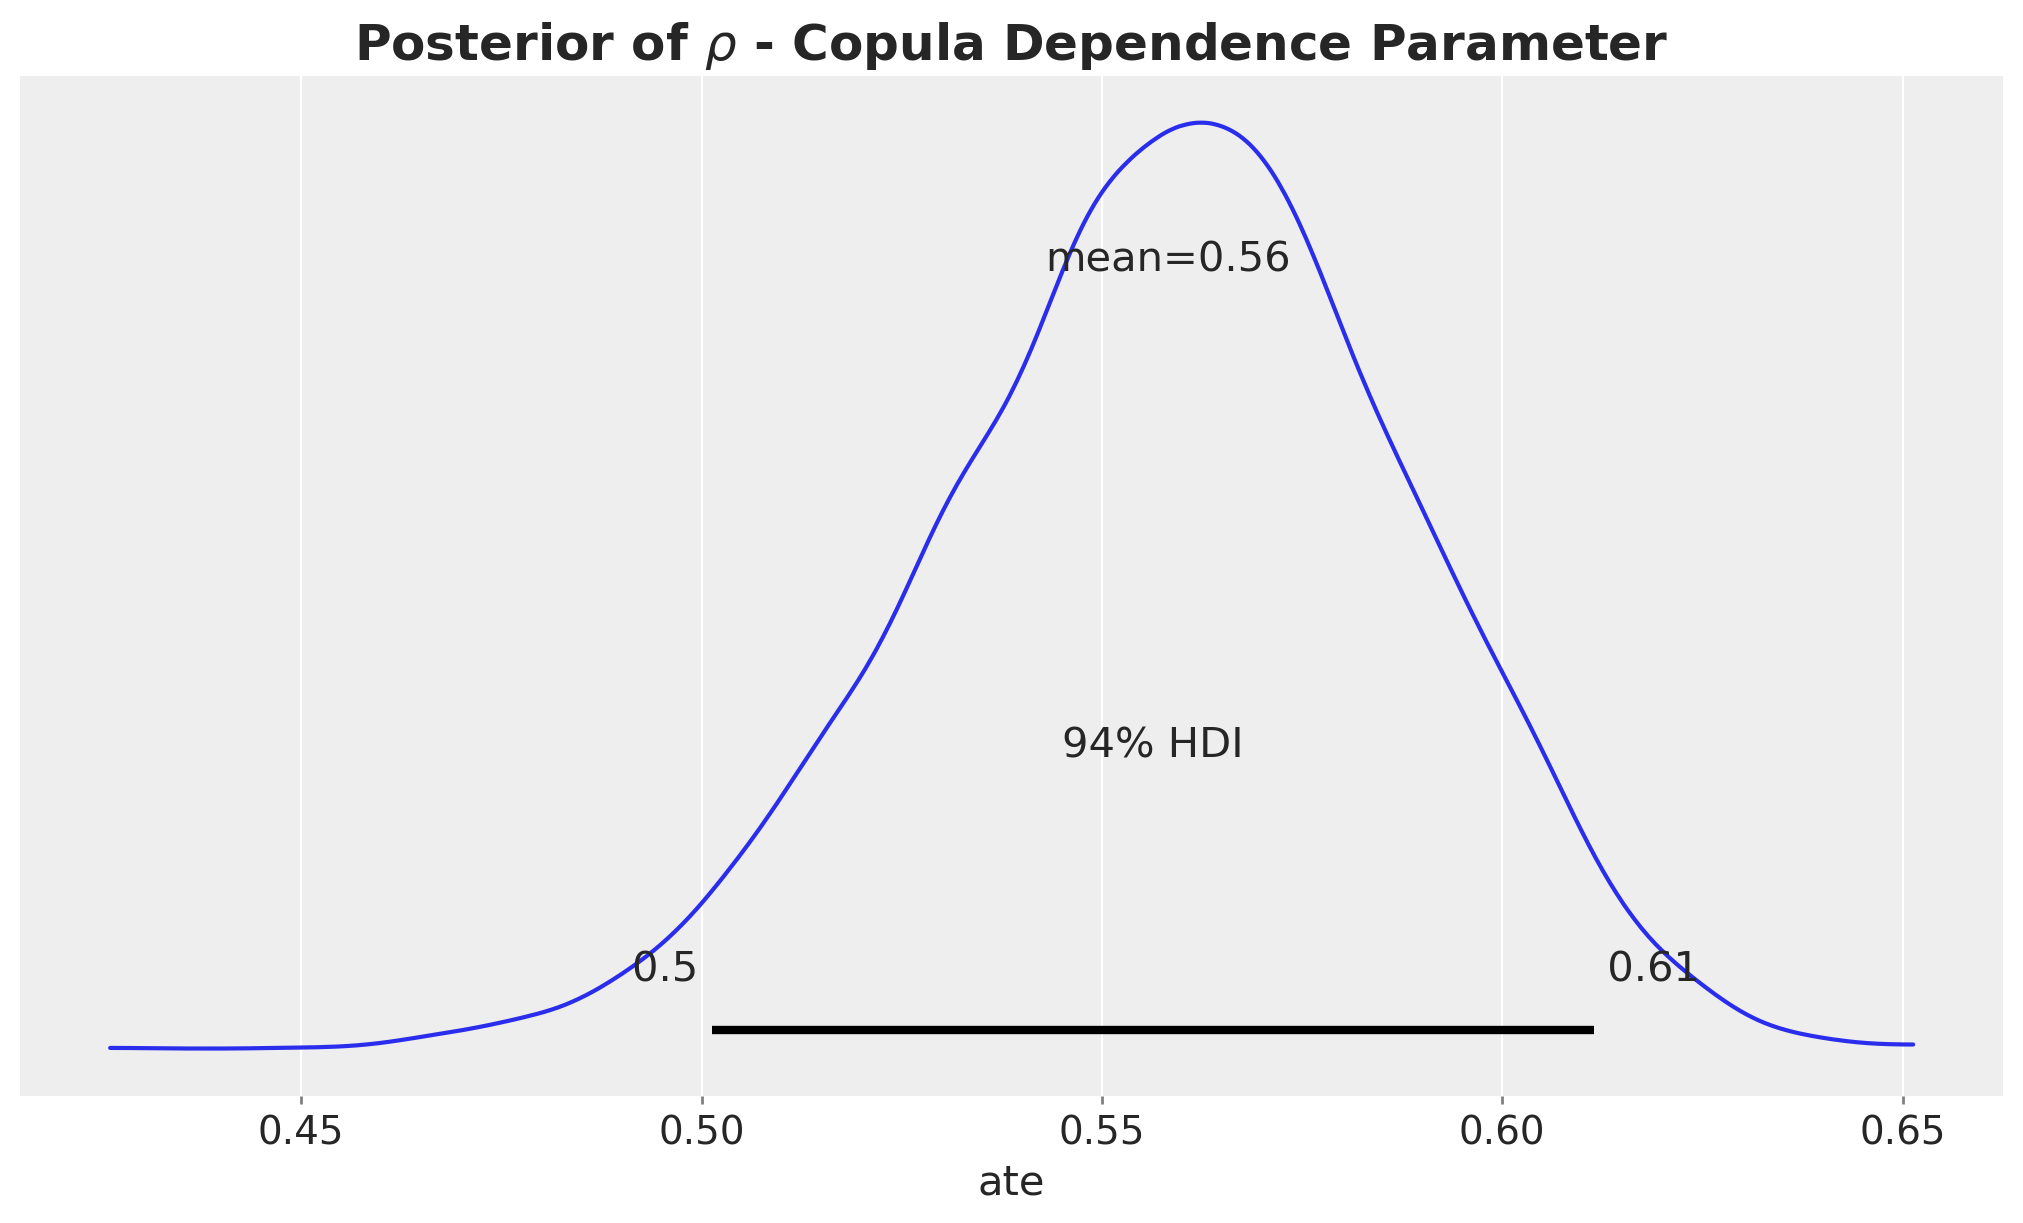

In [17]:
fig, ax = plt.subplots()
az.plot_posterior(idata_frugal, var_names=["rho"], ax=ax)
ax.set(xlabel="ate")
ax.set_title(
    r"Posterior of $\rho$ - Copula Dependence Parameter", fontsize=18, fontweight="bold"
);

## Comparison

In this linear Gaussian case, the two parameterizations should give essentially the same posterior for the ATE. The point is not that frugal is *better* here,
but that it opens the door to things you can't easily do with the standard approach.

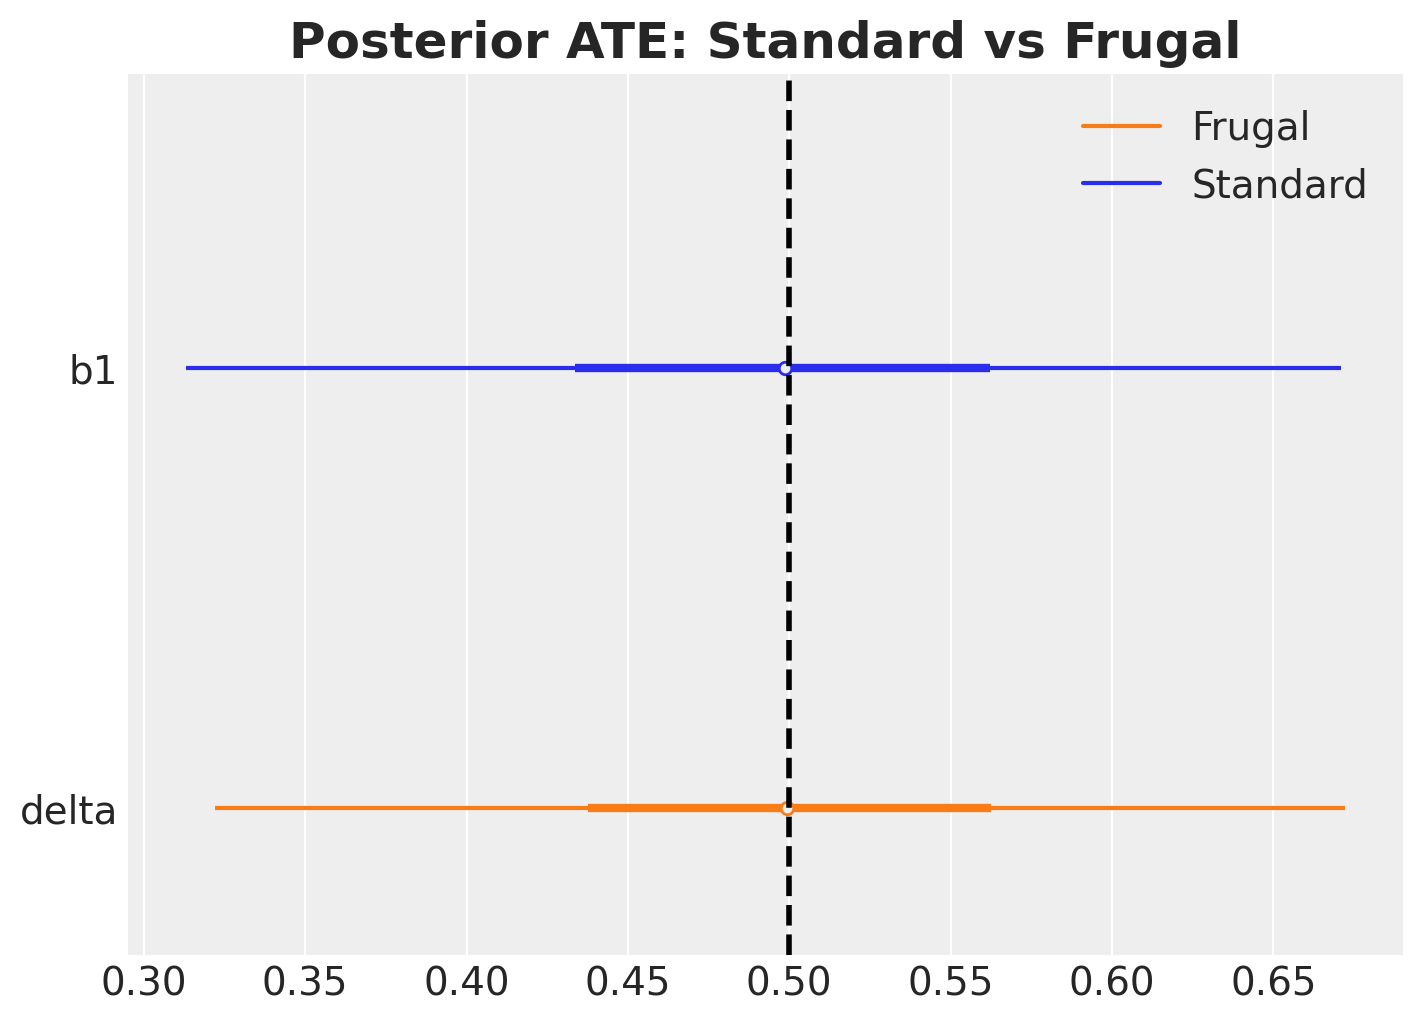

In [18]:
ax, *_ = az.plot_forest(
    [idata_standard, idata_frugal],
    model_names=["Standard", "Frugal"],
    var_names=["b1", "delta"],
    combined=True,
    figsize=(7, 5),
)
ax.axvline(TRUE_ATE, color="black", linestyle="--", lw=2)
ax.set_title("Posterior ATE: Standard vs Frugal", fontsize=18, fontweight="bold");

## The Payoff: Informative Priors on the Causal Effect

The real advantage of the frugal parameterization becomes clear when you have **prior knowledge about the causal effect itself**, which is extremely common in practice.

### Scenario: combining experimental and observational evidence

Imagine you are a data scientist at a company that has:

1. **A small experiment** (e.g., a geo-lift test, a pilot RCT, an A/B test) that gives a noisy estimate of the causal effect: $\hat{\delta} \approx 0.5 \pm 0.1$.
2. **A large observational dataset** where the treatment was deployed non-randomly and confounding is present.

You want to combine these two sources of information. With the frugal parameterization, this is trivial: put the experimental result as an informative prior on $\delta$.

With the standard parameterization, you would need to translate "$\delta \approx 0.5 \pm 0.1$" into priors on regression coefficients — which is not straightforward, especially if the model is non-linear.

Let's compare a vague prior $\delta \sim \mathcal{N}(0, 2)$ against an informative prior $\delta \sim \mathcal{N}(0.5, 0.1)$ in the frugal model.

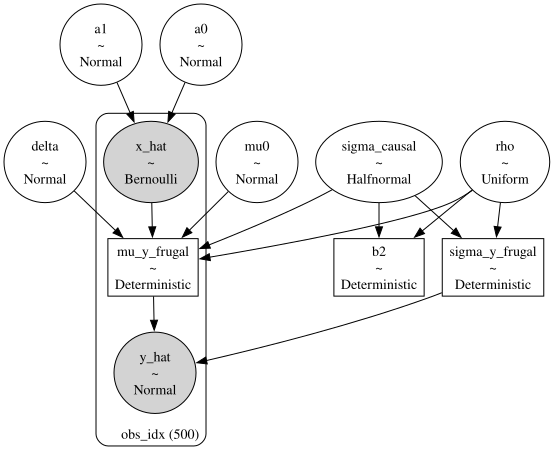

In [19]:
with pm.Model(coords=coords) as frugal_informative:
    # (a) The past
    a0 = pm.Normal("a0", 0, 2)
    a1 = pm.Normal("a1", 0, 2)
    x_hat = pm.Bernoulli(
        "x_hat", p=pm.math.invlogit(a0 + a1 * z_obs), observed=x_obs, dims="obs_idx"
    )

    # (b) Causal margin with INFORMATIVE prior on ATE
    mu0 = pm.Normal("mu0", 0, 2)  # E[Y | do(X=0)]
    delta = pm.Normal("delta", 0.5, 0.1)  # <-- from a pilot experiment
    sigma_causal = pm.HalfNormal("sigma_causal", 1)

    # --- (c) Dependence: Gaussian copula ---
    rho = pm.Uniform("rho", -0.95, 0.95)

    b2 = pm.Deterministic("b2", rho * sigma_causal)

    # --- Observational likelihood ---
    mu_y_frugal = pm.Deterministic(
        "mu_y_frugal", mu0 + delta * x_hat + rho * sigma_causal * z_obs, dims="obs_idx"
    )
    sigma_y_frugal = pm.Deterministic(
        "sigma_y_frugal",
        sigma_causal * pt.sqrt(1 - rho**2),
    )

    pm.Normal(
        "y_hat", mu=mu_y_frugal, sigma=sigma_y_frugal, observed=y_obs, dims="obs_idx"
    )

pm.model_to_graphviz(frugal_informative)

In [20]:
with frugal_informative:
    idata_informative = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        random_seed=seed,
        progressbar=True,
        return_inferencedata=True,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a0, a1, mu0, delta, sigma_causal, rho]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


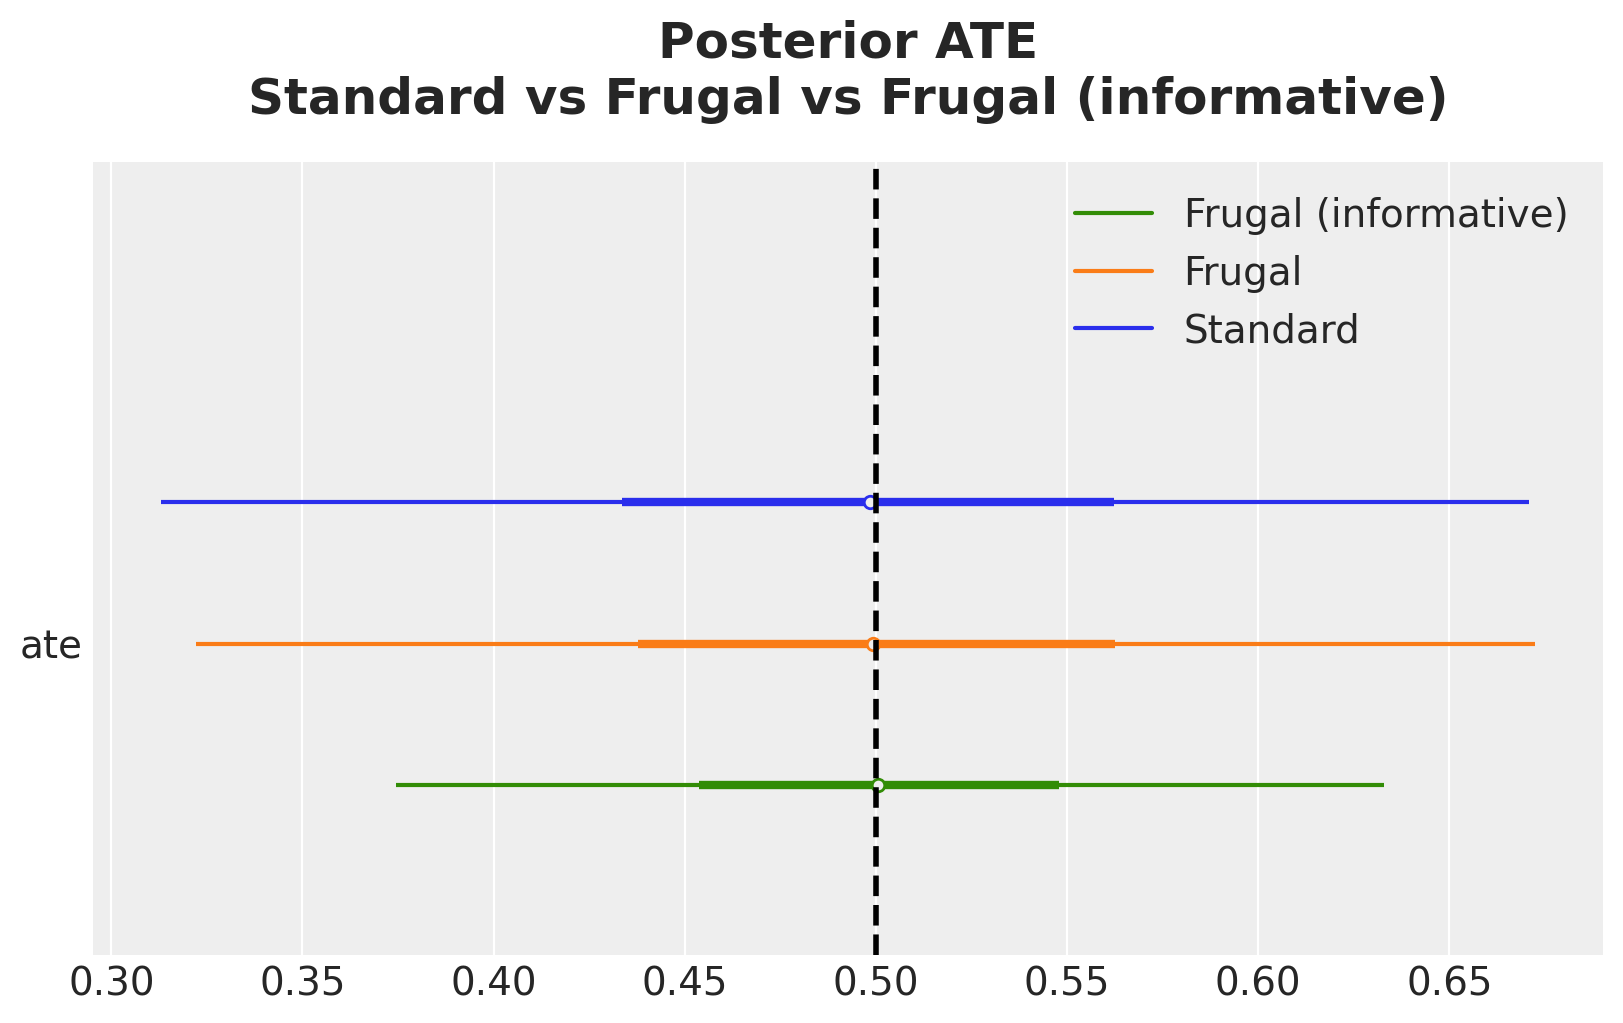

In [21]:
ax, *_ = az.plot_forest(
    [
        idata_standard.rename({"b1": "ate"}),
        idata_frugal.rename({"delta": "ate"}),
        idata_informative.rename({"delta": "ate"}),
    ],
    model_names=["Standard", "Frugal", "Frugal (informative)"],
    var_names=["ate"],
    combined=True,
    figsize=(8, 5),
)
ax.axvline(TRUE_ATE, color="black", linestyle="--", lw=2)
ax.set_title(
    "Posterior ATE\nStandard vs Frugal vs Frugal (informative)",
    fontsize=18,
    fontweight="bold",
    y=1.05,
);

The informative prior sharpens the posterior and pulls it closer to the true value. This is the Bayesian machinery doing exactly what it should: combining prior knowledge (from the experiment) with new evidence (from the observational data).

Note that the posterior is *not* just the prior — the data genuinely updates it. The posterior mean sits between the prior mean (0.5) and the vague-prior posterior, weighted by their relative precision.

## Inspecting the Copula Dependence Parameter

The copula correlation $\rho$ captures the residual association between $Y$ and $Z$ that is not explained by the causal effect of $X$ on $Y$. In the standard model, this role is played by $\beta_2$.

Let's verify that the two are consistent.

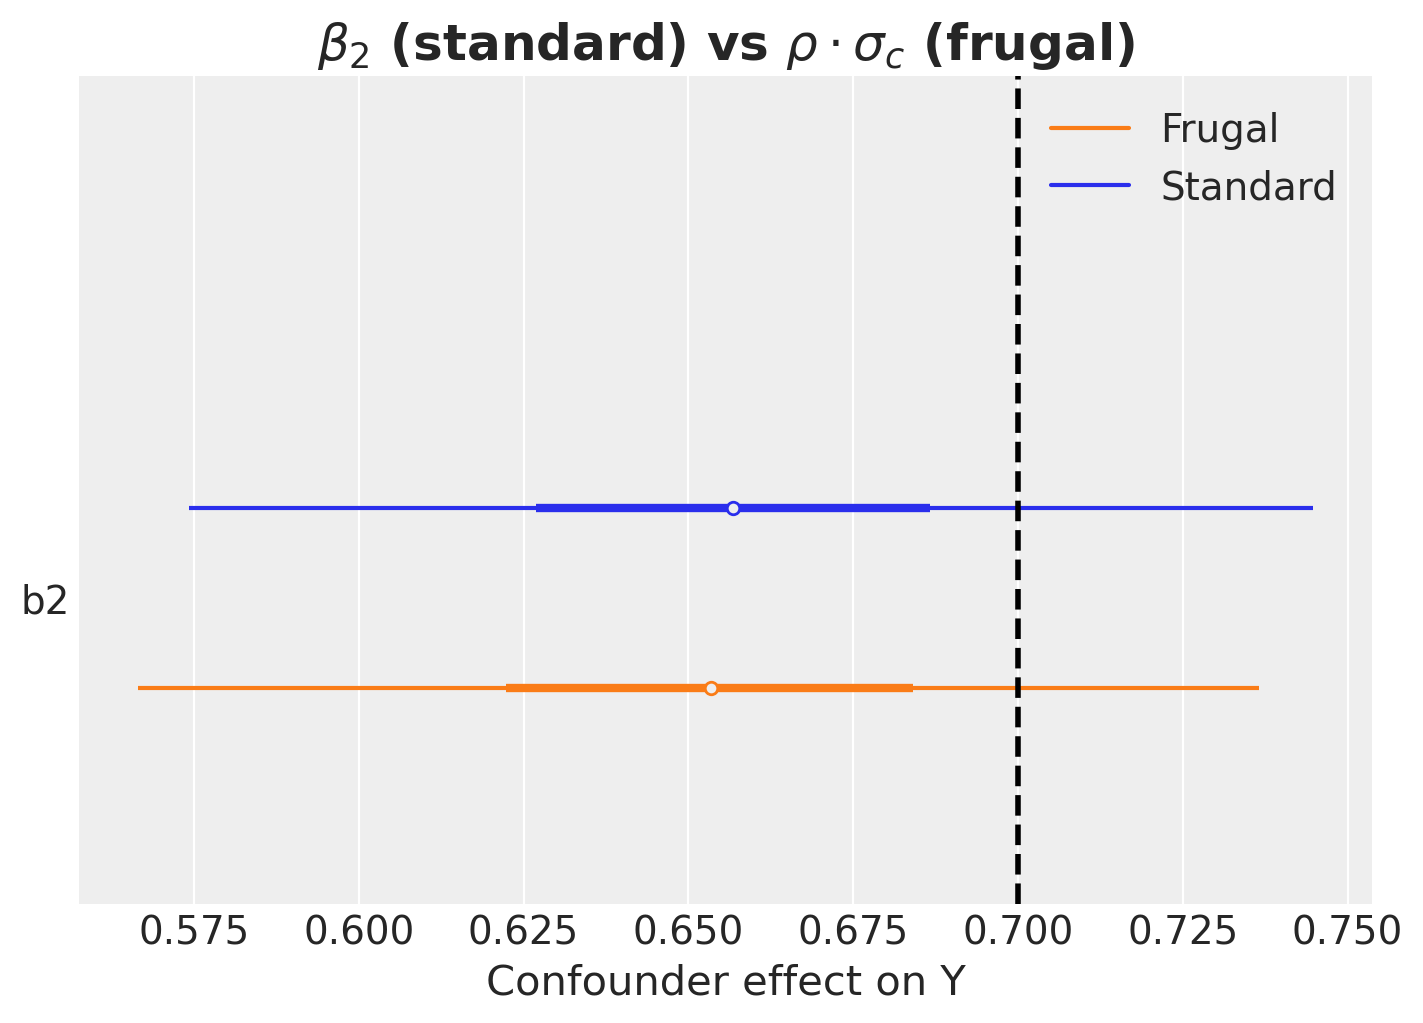

In [22]:
ax, *_ = az.plot_forest(
    [idata_standard, idata_frugal],
    model_names=["Standard", "Frugal"],
    var_names=["b2"],
    combined=True,
    figsize=(7, 5),
)
ax.axvline(beta_2, color="black", linestyle="--", lw=2, label=f"True beta_2 = {beta_2}")
ax.set(
    xlabel="Confounder effect on Y",
)
ax.set_title(
    r"$\beta_2$ (standard) vs $\rho \cdot \sigma_c$ (frugal)",
    fontsize=18,
    fontweight="bold",
);

The left panel shows the posterior of $\rho$. The right panel confirms that the frugal model's implied confounder effect ($\rho \cdot \sigma_c$) matches the standard model's $\beta_2$ — they are equivalent reparameterizations in the linear Gaussian case.

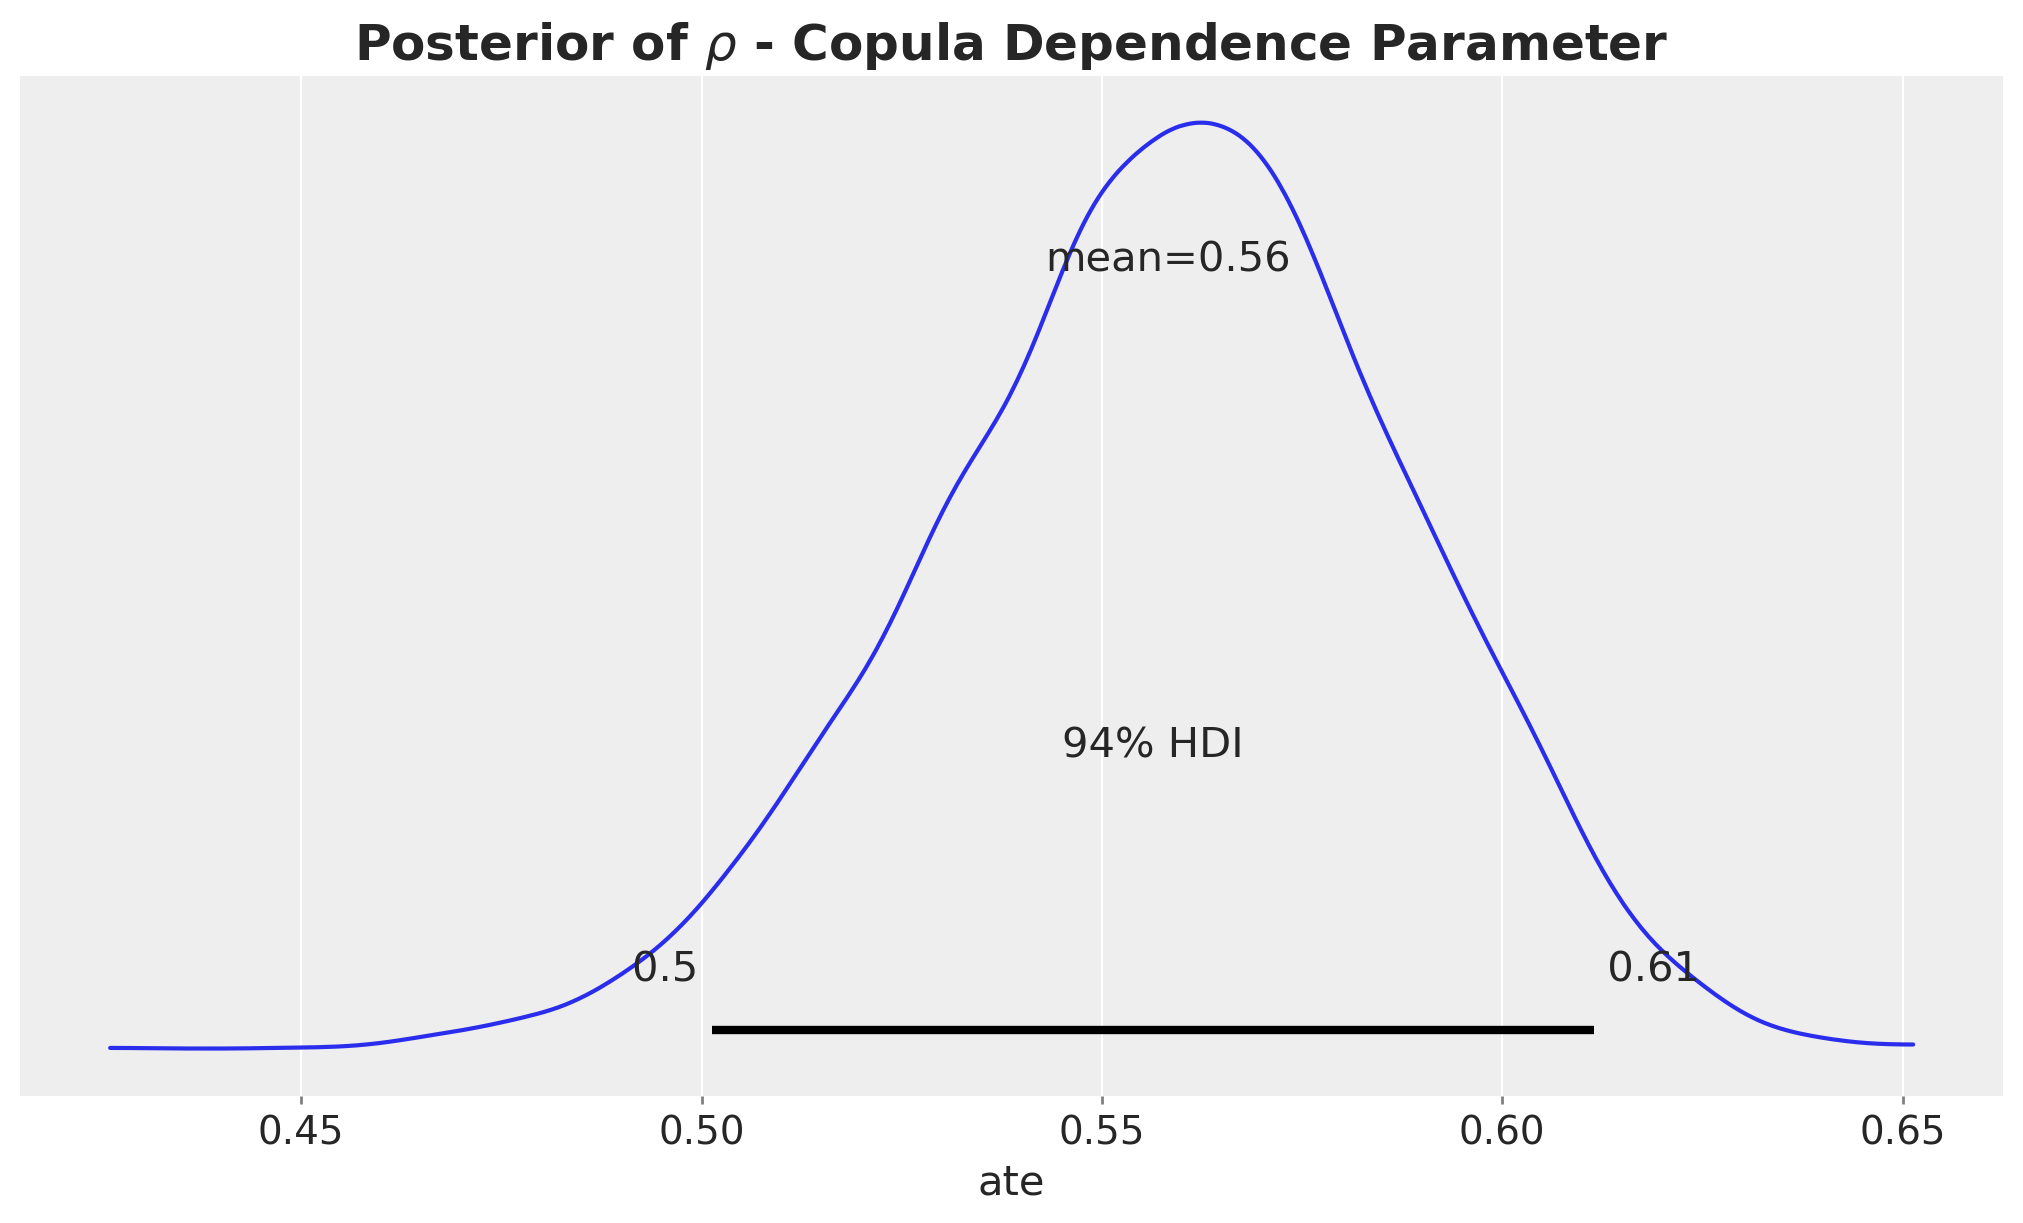

In [23]:
fig, ax = plt.subplots()
az.plot_posterior(idata_frugal, var_names=["rho"], ax=ax)
ax.set(xlabel="ate")
ax.set_title(
    r"Posterior of $\rho$ - Copula Dependence Parameter", fontsize=18, fontweight="bold"
);

## 6. Industry Applications

The frugal parameterization is especially valuable in settings where:

- You have **some experimental evidence** (a pilot, a geo-lift test, an A/B test)
  giving a noisy estimate of the causal effect, combined with **rich observational
  data** where confounding is present.
- The causal estimand is a **marginal quantity** (like ATE) that is not a single
  coefficient in the model.
- You want to do **prior sensitivity analysis** on the causal effect itself.

Concrete examples:

| Domain | Causal question | Why frugal helps |
|--------|----------------|------------------|
| **Marketing mix modeling** | Incremental revenue per $1K on TV | Encode geo-lift results as prior on $\delta$; copula handles seasonality confounding |
| **Drug pricing / HTA** | Effect of treatment on QALYs from claims data | Put RCT result as prior; update with real-world evidence |
| **Pricing & demand** | Price elasticity from observational sales data | Prior from past A/B tests; copula absorbs correlated demand shifters |
| **Insurance** | Effect of intervention on churn/claims | Pilot estimate as prior; fit on full non-randomized book |
| **Operations** | Effect of supplier switch on lead time | Process knowledge as prior; copula handles demand-driven confounding |

## 7. Limitations and Extensions

This notebook covers the **simplest possible case**: continuous Gaussian outcome, binary treatment, a single confounder, and a Gaussian copula. The Evans & Didelez framework is much more general:

- **Discrete outcomes:** Use odds ratios instead of copulas for the dependence component. The frugal parameterization works with log-linear models.

- **Non-Gaussian outcomes:** Use different copula families (Clayton, Frank, vine copulas) and/or different marginal distributions. The existing [PyMC copula example](https://www.pymc.io/projects/examples/en/latest/howto/copula-estimation.html) provides a starting point.

- **Continuous treatments:** The ATE generalizes to a dose-response curve. The causal margin becomes $P^*(Y \mid \text{do}(X=x))$ for continuous $x$.

- **Multiple confounders:** The copula extends to higher dimensions, though parameterization becomes more complex. Vine copulas are natural here.

- **Longitudinal settings (dynamic treatment regimes):** This is where the frugal parameterization really shines — and where Didelez's expertise is deepest. The causal margin becomes a marginal structural model (MSM), and the copula handles time-varying confounding. The R package `causl` implements this; a PyMC/NumPyro version does not yet exist.

- **Rejection sampling:** For non-Gaussian continuous outcomes, simulating from the frugal parameterization requires rejection sampling to connect the interventional parameterization back to the observational data. Evans & Didelez (2024, Section 5) provide the details

## 8. Summary

| | Standard | Frugal |
|---|---|---|
| **ATE is...** | a derived quantity | a direct parameter |
| **Priors on ATE** | indirect (via regression coefficients) | direct |
| **Simulation with known ATE** | hard (reverse-engineer conditionals) | easy (set $\delta$) |
| **Dependence structure** | regression coefficients | copula |
| **Variation independence** | not guaranteed | built in |
| **Bayesian prior independence** | not guaranteed | natural |
| **Non-linear models** | ATE is a complex function of parameters | ATE is still $\delta$ |

The frugal parameterization does not give you a *better* answer in the linear
Gaussian case — it gives you a *better language* for expressing your assumptions
and incorporating prior knowledge about causal effects. The payoff grows with
model complexity.